# MIT-BIH Binary Arrhythmia Classification with a 1D CNN

This notebook ports the MNIST convolutional-network example to single-lead ECG beats. Each row contains 187 voltage samples and one original class label. Labels are collapsed to **normal (0)** and **arrhythmia (1–4)**.

Important features:

- Every convolution uses a 5-sample kernel.
- Class-weighted binary cross-entropy addresses the strong normal/arrhythmia imbalance.
- Adaptive average pooling avoids a fragile hard-coded flattened size.
- The hidden-layer batch normalization is registered in `__init__`, so its learned state is trained and saved.
- Recall, specificity, F1, balanced accuracy, ROC-AUC, and the confusion matrix supplement accuracy.
- The supplied test CSV remains untouched until the final evaluation.

## Presentation experiment stages

Change only `EXPERIMENT_STAGE` in the next cell to run cumulative ablations:

1. `baseline` — ordinary binary loss, 0.5 threshold, and the final epoch.
2. `class_balancing` — adds inverse-frequency positive-class weighting.
3. `lower_threshold` — lowers the fixed threshold from 0.5 to 0.25.
4. `cost_sensitive` — makes a false negative ten times as costly as a false positive.
5. `best_epoch_selection` — chooses training duration from the best cross-validation epochs.
6. `target_recall` — selects the highest validation threshold meeting 99.5% recall, then maximizes specificity.

Each stage writes to a separate model filename and checkpoint directory. Run the complete notebook for each stage so comparisons use the same folds, seeds, and untouched test set.

In [ ]:
%matplotlib inline

from pathlib import Path
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, TensorDataset

from model_defintion import HeartbeatConvolutionalNetwork

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#111827',
    'axes.facecolor': '#111827',
    'savefig.facecolor': '#111827',
})

# These defaults make the notebook practical on both CPU and GPU.
NUM_EPOCHS = 25
NUM_FOLDS = 5
INITIAL_LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-3
RANDOM_SEED = 42
EVALUATION_BATCH_SIZE = 1024

# Select one cumulative presentation stage. Each stage adds exactly one intervention.
EXPERIMENT_STAGE = 'cost_sensitive'
EXPERIMENT_PRESETS = {
    'baseline': {
        'use_class_balancing': False,
        'decision_threshold': 0.5,
        'auto_select_threshold': False,
        'false_negative_cost': 1.0,
        'false_positive_cost': 1.0,
        'use_best_epoch': False,
        'selection_metric': 'balanced_accuracy',
    },
    'class_balancing': {
        'use_class_balancing': True,
        'decision_threshold': 0.5,
        'auto_select_threshold': False,
        'false_negative_cost': 1.0,
        'false_positive_cost': 1.0,
        'use_best_epoch': False,
        'selection_metric': 'balanced_accuracy',
    },
    'lower_threshold': {
        'use_class_balancing': True,
        'decision_threshold': 0.25,
        'auto_select_threshold': False,
        'false_negative_cost': 1.0,
        'false_positive_cost': 1.0,
        'use_best_epoch': False,
        'selection_metric': 'balanced_accuracy',
    },
    'cost_sensitive': {
        'use_class_balancing': True,
        'decision_threshold': 0.25,
        'auto_select_threshold': False,
        'false_negative_cost': 10.0,
        'false_positive_cost': 1.0,
        'use_best_epoch': False,
        'selection_metric': 'weighted_error_cost',
    },
    'best_epoch_selection': {
        'use_class_balancing': True,
        'decision_threshold': 0.25,
        'auto_select_threshold': False,
        'false_negative_cost': 10.0,
        'false_positive_cost': 1.0,
        'use_best_epoch': True,
        'selection_metric': 'weighted_error_cost',
    },
    'target_recall': {
        'use_class_balancing': True,
        'decision_threshold': 0.25,
        'auto_select_threshold': True,
        'false_negative_cost': 10.0,
        'false_positive_cost': 1.0,
        'use_best_epoch': True,
        'selection_metric': 'specificity',
    },
}
if EXPERIMENT_STAGE not in EXPERIMENT_PRESETS:
    raise ValueError(f'Unknown EXPERIMENT_STAGE: {EXPERIMENT_STAGE}')

experiment = EXPERIMENT_PRESETS[EXPERIMENT_STAGE]
USE_CLASS_BALANCING = experiment['use_class_balancing']
DECISION_THRESHOLD = experiment['decision_threshold']
AUTO_SELECT_DECISION_THRESHOLD = experiment['auto_select_threshold']
FALSE_NEGATIVE_COST = experiment['false_negative_cost']
FALSE_POSITIVE_COST = experiment['false_positive_cost']
USE_BEST_EPOCH_SELECTION = experiment['use_best_epoch']
MODEL_SELECTION_METRIC = experiment['selection_metric']
TARGET_RECALL = 0.995

ENABLE_CHECKPOINTING = True
CHECKPOINT_DIR = Path('checkpoints/heartbeat') / EXPERIMENT_STAGE
MODEL_PATH = Path(f'heartbeat_1d_cnn_{EXPERIMENT_STAGE}.pt')

if not 0.0 < DECISION_THRESHOLD < 1.0:
    raise ValueError('DECISION_THRESHOLD must be strictly between 0 and 1.')
if not 0.0 < TARGET_RECALL <= 1.0:
    raise ValueError('TARGET_RECALL must be greater than 0 and at most 1.')
if FALSE_NEGATIVE_COST <= 0 or FALSE_POSITIVE_COST <= 0:
    raise ValueError('FALSE_NEGATIVE_COST and FALSE_POSITIVE_COST must both be positive.')

print(f'Experiment stage: {EXPERIMENT_STAGE}')
for setting, value in experiment.items():
    print(f'  {setting}: {value}')

# Support execution from either the repository root or this notebook's directory.
DATA_DIR_CANDIDATES = [Path('data/source'), Path('../../data/source')]
DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Could not find data/source. Run from the repository root or examples/Heartbeat.')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'
print(f'Device: {DEVICE}')
if PIN_MEMORY:
    print(f'GPU: {torch.cuda.get_device_name(0)}')

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if PIN_MEMORY:
    torch.cuda.manual_seed_all(RANDOM_SEED)

Experiment stage: cost_sensitive
  use_class_balancing: True
  decision_threshold: 0.25
  auto_select_threshold: False
  false_negative_cost: 10.0
  false_positive_cost: 1.0
  use_best_epoch: False
  selection_metric: weighted_error_cost
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Ti


## Load and inspect the data

The source waveforms are already scaled to `[0, 1]`; keeping that representation also preserves the meaning of zero-padding at the end of shorter beats. The channel dimension added below changes each model input from `(187,)` to `(1, 187)`, as expected by `Conv1d`.

In [24]:
def load_heartbeat_csv(path):
    rows = np.loadtxt(path, delimiter=',', dtype=np.float32)
    if rows.ndim != 2 or rows.shape[1] != 188:
        raise ValueError(f'Expected 188 columns in {path}, found shape {rows.shape}')
    if not np.isfinite(rows).all():
        raise ValueError(f'Non-finite values found in {path}')

    signals = torch.from_numpy(rows[:, :-1]).unsqueeze(1)
    original_labels = torch.from_numpy(rows[:, -1].astype(np.int64))
    # Original class 0 is normal; all other classes become arrhythmia.
    binary_labels = (original_labels != 0).to(torch.float32)
    return TensorDataset(signals, binary_labels), original_labels


training_dataset, training_original_labels = load_heartbeat_csv(
    DATA_DIR / 'mitbih_train.csv'
)
test_dataset, test_original_labels = load_heartbeat_csv(
    DATA_DIR / 'mitbih_test.csv'
)

training_labels = training_dataset.tensors[1]
test_labels = test_dataset.tensors[1]

original_class_names = {
    0: 'N — Normal/non-ectopic',
    1: 'S — Supraventricular ectopic',
    2: 'V — Ventricular ectopic',
    3: 'F — Fusion',
    4: 'Q — Unknown/unclassifiable',
}

for split_name, labels, original_labels in [
    ('Training', training_labels, training_original_labels),
    ('Test', test_labels, test_original_labels),
]:
    normal = int((labels == 0).sum())
    arrhythmia = int((labels == 1).sum())
    print(
        f'{split_name}: {len(labels):,} beats | '
        f'normal {normal:,} ({normal / len(labels):.1%}) | '
        f'arrhythmia {arrhythmia:,} ({arrhythmia / len(labels):.1%})'
    )
    for class_value, class_name in original_class_names.items():
        class_count = int((original_labels == class_value).sum())
        print(
            f'  Class {class_value} ({class_name}): '
            f'{class_count:,} ({class_count / len(original_labels):.1%})'
        )

print(f'Input shape: {tuple(training_dataset.tensors[0].shape)}')

Training: 87,554 beats | normal 72,471 (82.8%) | arrhythmia 15,083 (17.2%)
  Class 0 (N — Normal/non-ectopic): 72,471 (82.8%)
  Class 1 (S — Supraventricular ectopic): 2,223 (2.5%)
  Class 2 (V — Ventricular ectopic): 5,788 (6.6%)
  Class 3 (F — Fusion): 641 (0.7%)
  Class 4 (Q — Unknown/unclassifiable): 6,431 (7.3%)
Test: 21,892 beats | normal 18,118 (82.8%) | arrhythmia 3,774 (17.2%)
  Class 0 (N — Normal/non-ectopic): 18,118 (82.8%)
  Class 1 (S — Supraventricular ectopic): 556 (2.5%)
  Class 2 (V — Ventricular ectopic): 1,448 (6.6%)
  Class 3 (F — Fusion): 162 (0.7%)
  Class 4 (Q — Unknown/unclassifiable): 1,608 (7.3%)
Input shape: (87554, 1, 187)


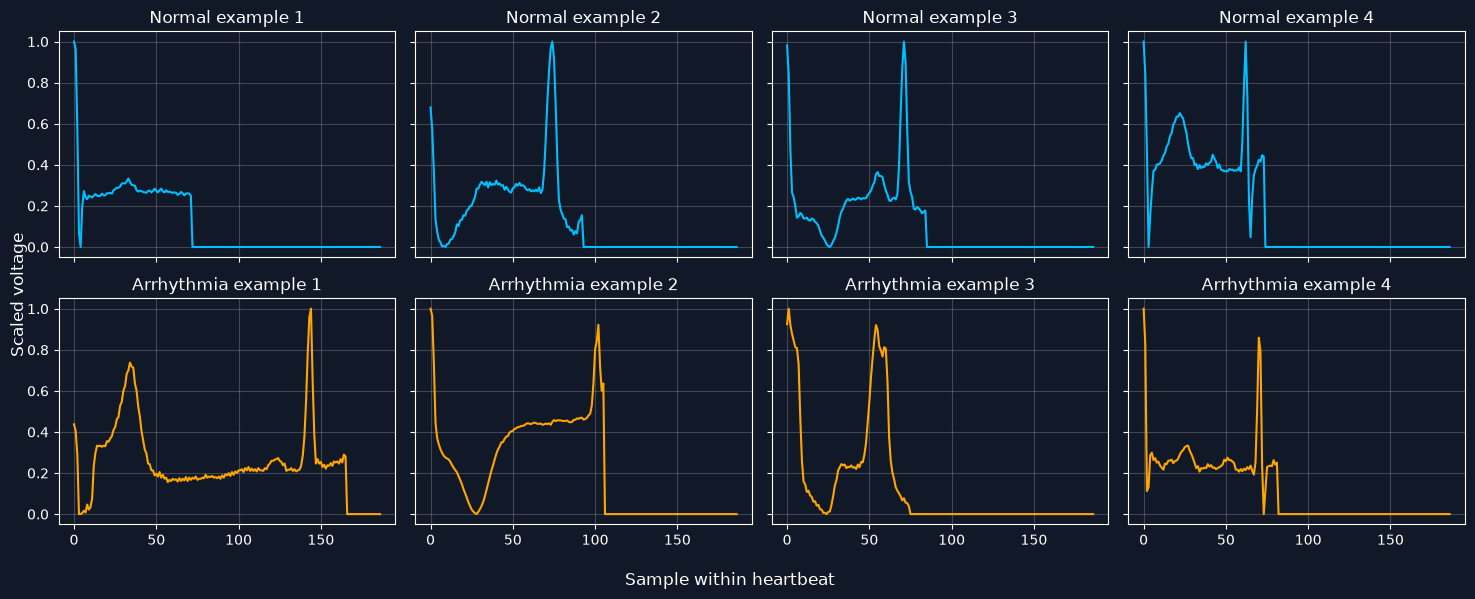

In [25]:
def plot_sample_beats(dataset, samples_per_class=4):
    signals, labels = dataset.tensors
    figure, axes = plt.subplots(2, samples_per_class, figsize=(15, 6), sharex=True, sharey=True)

    for class_value, class_name in [(0, 'Normal'), (1, 'Arrhythmia')]:
        class_indices = torch.where(labels == class_value)[0]
        random_order = torch.randperm(len(class_indices))[:samples_per_class]
        indices = class_indices[random_order]
        for column, index in enumerate(indices):
            axis = axes[class_value, column]
            axis.plot(signals[index, 0].numpy(), color='deepskyblue' if class_value == 0 else 'orange')
            axis.set_title(f'{class_name} example {column + 1}')
            axis.grid(alpha=0.2)

    figure.supxlabel('Sample within heartbeat')
    figure.supylabel('Scaled voltage')
    plt.tight_layout()
    plt.show()


plot_sample_beats(training_dataset)

## Model

A five-sample kernel lets each filter inspect a slightly wider local ECG neighborhood than the MNIST model's three-pixel kernel. Padding keeps sequence length unchanged inside each convolutional block; pooling progressively expands the effective receptive field. One output logit is sufficient for binary classification.

In [26]:
def create_model(seed):
    torch.manual_seed(seed)
    if PIN_MEMORY:
        torch.cuda.manual_seed_all(seed)
    return HeartbeatConvolutionalNetwork().to(DEVICE)


model_preview = create_model(RANDOM_SEED)
print(model_preview)
print(f'\nTrainable parameters: {sum(p.numel() for p in model_preview.parameters() if p.requires_grad):,}')
with torch.no_grad():
    preview_logits = model_preview(torch.zeros(2, 1, 187, device=DEVICE))
print(f'Output shape for two beats: {tuple(preview_logits.shape)}')
del model_preview

HeartbeatConvolutionalNetwork(
  (features): Sequential(
    (0): ConvolutionalBlock1D(
      (conv): Conv1d(1, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (batch_norm): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (activation): GELU(approximate='none')
    )
    (1): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    (2): ConvolutionalBlock1D(
      (conv): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (batch_norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (activation): GELU(approximate='none')
    )
    (3): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    (4): ConvolutionalBlock1D(
      (conv): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (batch_norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (activation): GELU(

## Stratified cross-validation and data loaders

Each fold keeps roughly the same normal/arrhythmia ratio. The official test file is not used to form folds or tune the model.

In [27]:
class BatchSizeManager:
    BATCH_SIZES = [64, 128, 256, 512]

    @classmethod
    def get_batch_size(cls, epoch):
        return cls.BATCH_SIZES[min(epoch // 5, len(cls.BATCH_SIZES) - 1)]


def make_stratified_folds(labels, num_folds, seed):
    generator = torch.Generator().manual_seed(seed)
    fold_parts = [[] for _ in range(num_folds)]

    for class_value in (0, 1):
        class_indices = torch.where(labels == class_value)[0]
        class_indices = class_indices[
            torch.randperm(len(class_indices), generator=generator)
        ]
        for fold_index, indices in enumerate(torch.tensor_split(class_indices, num_folds)):
            fold_parts[fold_index].append(indices)

    folds = []
    for parts in fold_parts:
        indices = torch.cat(parts)
        indices = indices[torch.randperm(len(indices), generator=generator)]
        folds.append(indices)
    return folds


def get_num_workers():
    # A conservative cap works well in notebooks and avoids spawning dozens of workers.
    return min(4, max(0, (os.cpu_count() or 1) // 2))


def make_loader(dataset, batch_size, shuffle, seed=RANDOM_SEED):
    generator = torch.Generator().manual_seed(seed) if shuffle else None
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=get_num_workers(),
        pin_memory=PIN_MEMORY,
        generator=generator,
    )


fold_indices = make_stratified_folds(training_labels, NUM_FOLDS, RANDOM_SEED)
print(f'Fold sizes: {[len(indices) for indices in fold_indices]}')
for fold_number, indices in enumerate(fold_indices, start=1):
    print(f'Fold {fold_number}: {training_labels[indices].mean().item():.1%} arrhythmia')

Fold sizes: [17512, 17511, 17511, 17510, 17510]
Fold 1: 17.2% arrhythmia
Fold 2: 17.2% arrhythmia
Fold 3: 17.2% arrhythmia
Fold 4: 17.2% arrhythmia
Fold 5: 17.2% arrhythmia


In [28]:
def positive_class_weight(labels):
    negative_count = (labels == 0).sum().float()
    positive_count = (labels == 1).sum().float()
    if USE_CLASS_BALANCING:
        class_balance_weight = negative_count / positive_count
    else:
        class_balance_weight = torch.tensor(1.0)
    error_cost_ratio = FALSE_NEGATIVE_COST / FALSE_POSITIVE_COST
    return (class_balance_weight * error_cost_ratio).to(DEVICE)


def binary_metrics(labels, probabilities, threshold):
    labels = np.asarray(labels, dtype=np.int64)
    predictions = (np.asarray(probabilities) >= threshold).astype(np.int64)

    true_negative = int(((labels == 0) & (predictions == 0)).sum())
    false_positive = int(((labels == 0) & (predictions == 1)).sum())
    false_negative = int(((labels == 1) & (predictions == 0)).sum())
    true_positive = int(((labels == 1) & (predictions == 1)).sum())

    precision = true_positive / max(true_positive + false_positive, 1)
    recall = true_positive / max(true_positive + false_negative, 1)
    specificity = true_negative / max(true_negative + false_positive, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    accuracy = (true_positive + true_negative) / len(labels)
    false_negative_rate = false_negative / max(false_negative + true_positive, 1)
    false_positive_rate = false_positive / max(false_positive + true_negative, 1)
    weighted_error_cost = (
        FALSE_NEGATIVE_COST * false_negative
        + FALSE_POSITIVE_COST * false_positive
    ) / len(labels)

    # Integrate the empirical ROC curve, grouping tied scores at the same threshold.
    probabilities = np.asarray(probabilities)
    order = np.argsort(-probabilities, kind='stable')
    sorted_labels = labels[order]
    sorted_probabilities = probabilities[order]
    threshold_indices = np.r_[
        np.where(np.diff(sorted_probabilities))[0],
        len(sorted_probabilities) - 1,
    ]
    cumulative_true_positives = np.cumsum(sorted_labels)[threshold_indices]
    cumulative_false_positives = 1 + threshold_indices - cumulative_true_positives
    true_positive_rates = np.r_[0, cumulative_true_positives / max((labels == 1).sum(), 1)]
    false_positive_rates = np.r_[0, cumulative_false_positives / max((labels == 0).sum(), 1)]
    auc = float(np.trapezoid(true_positive_rates, false_positive_rates))

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'f1': f1,
        'balanced_accuracy': (recall + specificity) / 2,
        'roc_auc': auc,
        'false_negatives': false_negative,
        'false_positives': false_positive,
        'false_negative_rate': false_negative_rate,
        'false_positive_rate': false_positive_rate,
        'weighted_error_cost': weighted_error_cost,
        'confusion': np.array([[true_negative, false_positive], [false_negative, true_positive]]),
    }


def threshold_for_target_recall(labels, probabilities, target_recall):
    """Return the highest threshold that attains target recall on validation data."""
    labels = np.asarray(labels, dtype=np.int64)
    probabilities = np.asarray(probabilities)
    positive_probabilities = np.sort(probabilities[labels == 1])[::-1]
    if len(positive_probabilities) == 0:
        raise ValueError('Cannot select a recall threshold without positive examples.')

    required_true_positives = int(np.ceil(target_recall * len(positive_probabilities)))
    return float(positive_probabilities[required_true_positives - 1])


def select_validation_threshold(labels, probabilities):
    if AUTO_SELECT_DECISION_THRESHOLD:
        return threshold_for_target_recall(labels, probabilities, TARGET_RECALL)
    return DECISION_THRESHOLD


def model_selection_score(validation_metrics):
    """Convert every selection objective to a score where larger is better."""
    metric_value = validation_metrics[MODEL_SELECTION_METRIC]
    return -metric_value if MODEL_SELECTION_METRIC == 'weighted_error_cost' else metric_value


def run_training_epoch(model, optimizer, loss_fn, loader, decision_threshold):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for signals, labels in loader:
        signals = signals.to(DEVICE, non_blocking=PIN_MEMORY)
        labels = labels.to(DEVICE, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True)
        logits = model(signals)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        predicted_arrhythmia = torch.sigmoid(logits) >= decision_threshold
        correct += (predicted_arrhythmia == labels.bool()).sum().item()
        total += batch_size

    return total_loss / total, correct / total


def evaluate_model(model, loss_fn, loader, decision_threshold):
    model.eval()
    total_loss = 0.0
    all_probabilities = []
    all_labels = []

    with torch.inference_mode():
        for signals, labels in loader:
            signals = signals.to(DEVICE, non_blocking=PIN_MEMORY)
            labels_on_device = labels.to(DEVICE, non_blocking=PIN_MEMORY)
            logits = model(signals)

            total_loss += loss_fn(logits, labels_on_device).item() * labels.size(0)
            all_probabilities.append(torch.sigmoid(logits).cpu())
            all_labels.append(labels)

    probabilities = torch.cat(all_probabilities).numpy()
    labels = torch.cat(all_labels).numpy()
    metrics = binary_metrics(labels, probabilities, decision_threshold)
    metrics['loss'] = total_loss / len(labels)
    return metrics, labels, probabilities


def save_best_model_checkpoint(path, model, epoch, validation_metrics):
    """Save a fold model only when it sets a new best validation score."""
    if not ENABLE_CHECKPOINTING or not USE_BEST_EPOCH_SELECTION:
        return

    path.parent.mkdir(parents=True, exist_ok=True)
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'best_epoch': epoch,
        'selection_metric': MODEL_SELECTION_METRIC,
        'selection_value': validation_metrics[MODEL_SELECTION_METRIC],
        'false_negative_cost': FALSE_NEGATIVE_COST,
        'false_positive_cost': FALSE_POSITIVE_COST,
        'validation_metrics': {
            key: value
            for key, value in validation_metrics.items()
            if key != 'confusion'
        },
        'decision_threshold': validation_metrics['decision_threshold'],
        'target_recall': TARGET_RECALL,
    }
    temporary_path = path.with_suffix(path.suffix + '.tmp')
    torch.save(checkpoint, temporary_path)
    temporary_path.replace(path)

## Cross-validation training

When enabled by the selected experiment stage, the positive loss weight combines class balancing with `FALSE_NEGATIVE_COST / FALSE_POSITIVE_COST`. For example, costs of 10 and 1 treat a missed arrhythmia as ten times as harmful as a false alarm, in addition to correcting the class imbalance. These are simulation parameters, not clinically validated costs.

When `AUTO_SELECT_DECISION_THRESHOLD = True`, each epoch uses the highest validation threshold that still attains `TARGET_RECALL`. Among those candidates, checkpoint selection maximizes specificity, directly minimizing false positives subject to the recall requirement. `DECISION_THRESHOLD` is used only as the fallback when automatic selection is disabled.

For an unbiased final test result, the final threshold is selected from pooled out-of-fold predictions; the test set is never involved. In stages using best-epoch selection, `ENABLE_CHECKPOINTING = True` saves each fold's best model under its stage-specific `CHECKPOINT_DIR`. Cross-validation chooses the final training duration from the median best epoch, then a fresh model trains on the complete training set for that many epochs.

In [29]:
fold_histories = []
best_out_of_fold_labels = []
best_out_of_fold_probabilities = []
cross_validation_start = time.time()

for fold_index in range(NUM_FOLDS):
    validation_indices = fold_indices[fold_index]
    training_indices = torch.cat([
        indices for index, indices in enumerate(fold_indices) if index != fold_index
    ])
    fold_training_dataset = Subset(training_dataset, training_indices.tolist())
    fold_validation_dataset = Subset(training_dataset, validation_indices.tolist())
    fold_training_labels = training_labels[training_indices]

    fold_model = create_model(RANDOM_SEED + fold_index)
    fold_loss_fn = nn.BCEWithLogitsLoss(
        pos_weight=positive_class_weight(fold_training_labels)
    )
    fold_optimizer = torch.optim.AdamW(
        fold_model.parameters(),
        lr=INITIAL_LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    fold_scheduler = torch.optim.lr_scheduler.StepLR(
        fold_optimizer, step_size=5, gamma=0.85
    )
    validation_loader = make_loader(
        fold_validation_dataset, EVALUATION_BATCH_SIZE, shuffle=False
    )
    history = {
        'training_losses': [],
        'training_accuracies': [],
        'validation_losses': [],
        'validation_accuracies': [],
        'validation_recalls': [],
        'validation_specificities': [],
        'validation_f1s': [],
        'validation_roc_aucs': [],
        'validation_weighted_error_costs': [],
    }
    fold_checkpoint_path = CHECKPOINT_DIR / f'best_fold_{fold_index + 1}.pt'
    best_selection_score = -np.inf
    best_epoch = 0
    best_validation_metrics = None
    best_fold_labels = None
    best_fold_probabilities = None

    print(f'\nFold {fold_index + 1}/{NUM_FOLDS}: '
          f'{len(fold_training_dataset):,} train, {len(fold_validation_dataset):,} validation')

    for epoch in range(NUM_EPOCHS):
        batch_size = BatchSizeManager.get_batch_size(epoch)
        training_loader = make_loader(
            fold_training_dataset,
            batch_size,
            shuffle=True,
            seed=RANDOM_SEED + fold_index * NUM_EPOCHS + epoch,
        )
        training_loss, training_accuracy = run_training_epoch(
            fold_model,
            fold_optimizer,
            fold_loss_fn,
            training_loader,
            DECISION_THRESHOLD,
        )
        initial_metrics, validation_labels, validation_probabilities = evaluate_model(
            fold_model,
            fold_loss_fn,
            validation_loader,
            DECISION_THRESHOLD,
        )
        validation_threshold = select_validation_threshold(
            validation_labels, validation_probabilities
        )
        validation_metrics = binary_metrics(
            validation_labels, validation_probabilities, validation_threshold
        )
        validation_metrics['loss'] = initial_metrics['loss']
        validation_metrics['decision_threshold'] = validation_threshold

        history['training_losses'].append(training_loss)
        history['training_accuracies'].append(training_accuracy)
        history['validation_losses'].append(validation_metrics['loss'])
        history['validation_accuracies'].append(validation_metrics['accuracy'])
        history['validation_recalls'].append(validation_metrics['recall'])
        history['validation_specificities'].append(validation_metrics['specificity'])
        history['validation_f1s'].append(validation_metrics['f1'])
        history['validation_roc_aucs'].append(validation_metrics['roc_auc'])
        history['validation_weighted_error_costs'].append(
            validation_metrics['weighted_error_cost']
        )

        print(
            f'Epoch {epoch + 1:2d}/{NUM_EPOCHS} | batch {batch_size:3d} | '
            f'train loss {training_loss:.4f}, acc {training_accuracy:.3f} | '
            f'val loss {validation_metrics["loss"]:.4f}, '
            f'recall {validation_metrics["recall"]:.3f}, '
            f'specificity {validation_metrics["specificity"]:.3f}, '
            f'threshold {validation_threshold:.3f}, '
            f'FN {validation_metrics["false_negatives"]}, '
            f'FP {validation_metrics["false_positives"]}, '
            f'cost {validation_metrics["weighted_error_cost"]:.4f}, '
            f'AUC {validation_metrics["roc_auc"]:.3f}'
        )
        fold_scheduler.step()

        selection_score = model_selection_score(validation_metrics)
        use_this_epoch = (
            not USE_BEST_EPOCH_SELECTION
            or selection_score > best_selection_score
        )
        if use_this_epoch:
            best_selection_score = selection_score
            best_epoch = epoch + 1
            best_validation_metrics = validation_metrics.copy()
            best_fold_labels = validation_labels.copy()
            best_fold_probabilities = validation_probabilities.copy()
            save_best_model_checkpoint(
                fold_checkpoint_path,
                fold_model,
                best_epoch,
                validation_metrics,
            )

    history['best_epoch'] = best_epoch
    history['best_validation_metrics'] = best_validation_metrics
    best_out_of_fold_labels.append(best_fold_labels)
    best_out_of_fold_probabilities.append(best_fold_probabilities)
    best_metric_value = best_validation_metrics[MODEL_SELECTION_METRIC]
    selection_label = 'Best' if USE_BEST_EPOCH_SELECTION else 'Final'
    print(
        f'{selection_label} fold {fold_index + 1} {MODEL_SELECTION_METRIC}: '
        f'{best_metric_value:.4f} at epoch {best_epoch} | '
        f'threshold {best_validation_metrics["decision_threshold"]:.4f}'
    )
    fold_histories.append(history)
    del fold_model, fold_optimizer, fold_scheduler, validation_loader
    if PIN_MEMORY:
        torch.cuda.empty_cache()

elapsed = time.time() - cross_validation_start
print(f'\nCross-validation completed in {elapsed / 60:.1f} minutes')
for metric_key, label in [
    ('accuracy', 'Accuracy'),
    ('balanced_accuracy', 'Balanced accuracy'),
    ('recall', 'Arrhythmia recall'),
    ('specificity', 'Specificity'),
    ('false_negative_rate', 'False-negative rate'),
    ('false_positive_rate', 'False-positive rate'),
    ('weighted_error_cost', 'Weighted error cost'),
    ('f1', 'F1'),
    ('roc_auc', 'ROC-AUC'),
]:
    best_values = np.array([
        history['best_validation_metrics'][metric_key]
        for history in fold_histories
    ])
    print(f'{label:18s}: {best_values.mean():.4f} ± {best_values.std(ddof=1):.4f}')

best_epochs = np.array([history['best_epoch'] for history in fold_histories])
if USE_BEST_EPOCH_SELECTION:
    FINAL_NUM_EPOCHS = int(np.median(best_epochs))
    print(f'Best epochs by fold: {best_epochs.tolist()}')
    print(f'Final model will train for {FINAL_NUM_EPOCHS} epochs (fold median).')
else:
    FINAL_NUM_EPOCHS = NUM_EPOCHS
    print(f'Best-epoch selection disabled; final model will train for {FINAL_NUM_EPOCHS} epochs.')

pooled_validation_labels = np.concatenate(best_out_of_fold_labels)
pooled_validation_probabilities = np.concatenate(best_out_of_fold_probabilities)
FINAL_DECISION_THRESHOLD = select_validation_threshold(
    pooled_validation_labels, pooled_validation_probabilities
)
pooled_validation_metrics = binary_metrics(
    pooled_validation_labels,
    pooled_validation_probabilities,
    FINAL_DECISION_THRESHOLD,
)
print(f'Validation-selected decision threshold: {FINAL_DECISION_THRESHOLD:.4f}')
print(
    f'Pooled out-of-fold recall: {pooled_validation_metrics["recall"]:.4f} | '
    f'specificity: {pooled_validation_metrics["specificity"]:.4f} | '
    f'FN: {pooled_validation_metrics["false_negatives"]} | '
    f'FP: {pooled_validation_metrics["false_positives"]}'
)


Fold 1/5: 70,042 train, 17,512 validation
Epoch  1/25 | batch  64 | train loss 1.0753, acc 0.522 | val loss 0.9965, recall 0.988, specificity 0.549, threshold 0.250, FN 36, FP 6544, cost 0.3942, AUC 0.976
Epoch  2/25 | batch  64 | train loss 0.6920, acc 0.704 | val loss 0.7055, recall 0.993, specificity 0.714, threshold 0.250, FN 21, FP 4147, cost 0.2488, AUC 0.988
Epoch  3/25 | batch  64 | train loss 0.5374, acc 0.771 | val loss 0.6222, recall 0.995, specificity 0.683, threshold 0.250, FN 16, FP 4590, cost 0.2712, AUC 0.991
Epoch  4/25 | batch  64 | train loss 0.4588, acc 0.813 | val loss 0.4654, recall 0.994, specificity 0.848, threshold 0.250, FN 17, FP 2196, cost 0.1351, AUC 0.995
Epoch  5/25 | batch  64 | train loss 0.4081, acc 0.841 | val loss 0.4467, recall 0.993, specificity 0.892, threshold 0.250, FN 22, FP 1568, cost 0.1021, AUC 0.996
Epoch  6/25 | batch 128 | train loss 0.2488, acc 0.900 | val loss 0.4039, recall 0.994, specificity 0.889, threshold 0.250, FN 18, FP 1610, co

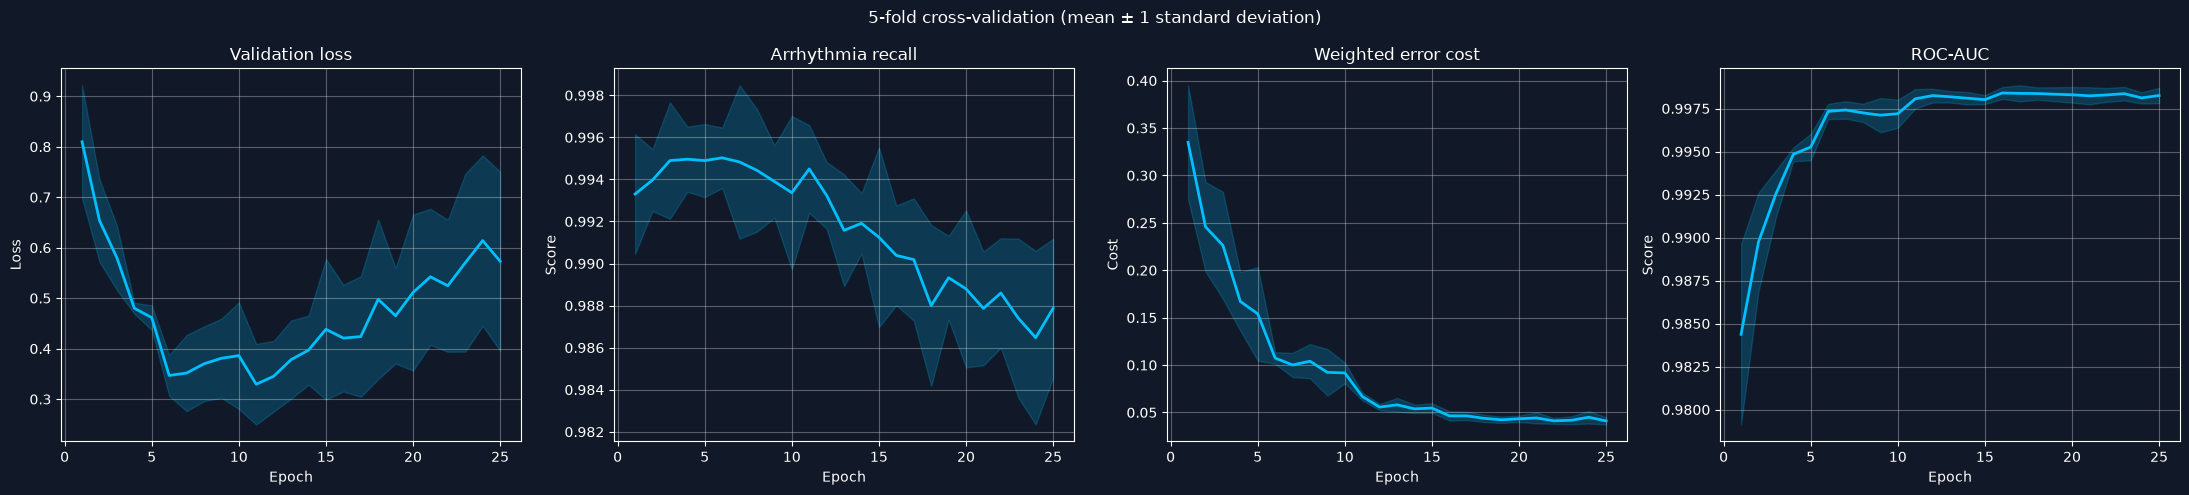

In [30]:
def plot_cross_validation_history(histories):
    epochs = np.arange(1, NUM_EPOCHS + 1)
    figure, axes = plt.subplots(1, 4, figsize=(22, 5))
    plot_specs = [
        ('validation_losses', 'Validation loss', 'Loss'),
        ('validation_recalls', 'Arrhythmia recall', 'Score'),
        ('validation_weighted_error_costs', 'Weighted error cost', 'Cost'),
        ('validation_roc_aucs', 'ROC-AUC', 'Score'),
    ]

    for axis, (key, title, ylabel) in zip(axes, plot_specs):
        values = np.array([history[key] for history in histories])
        mean = values.mean(axis=0)
        std = values.std(axis=0)
        axis.plot(epochs, mean, color='deepskyblue', linewidth=2)
        axis.fill_between(epochs, mean - std, mean + std, color='deepskyblue', alpha=0.2)
        axis.set_title(title)
        axis.set_xlabel('Epoch')
        axis.set_ylabel(ylabel)
        axis.grid(alpha=0.3)

    figure.suptitle(f'{NUM_FOLDS}-fold cross-validation (mean ± 1 standard deviation)')
    plt.tight_layout()
    plt.show()


plot_cross_validation_history(fold_histories)

## Train the final model and evaluate once on the test set

Cross-validation estimates generalization but does not yield a single deployable model. This section starts from fresh weights, trains on every row in `mitbih_train.csv`, saves the model, and then evaluates exactly once on `mitbih_test.csv`.

In [31]:
heartbeat_model = create_model(RANDOM_SEED + NUM_FOLDS)
final_pos_weight = positive_class_weight(training_labels)
final_loss_fn = nn.BCEWithLogitsLoss(pos_weight=final_pos_weight)
final_optimizer = torch.optim.AdamW(
    heartbeat_model.parameters(),
    lr=INITIAL_LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
final_scheduler = torch.optim.lr_scheduler.StepLR(
    final_optimizer, step_size=5, gamma=0.85
)

final_training_start = time.time()
for epoch in range(FINAL_NUM_EPOCHS):
    batch_size = BatchSizeManager.get_batch_size(epoch)
    training_loader = make_loader(
        training_dataset,
        batch_size,
        shuffle=True,
        seed=RANDOM_SEED + NUM_FOLDS * NUM_EPOCHS + epoch,
    )
    loss, accuracy = run_training_epoch(
        heartbeat_model,
        final_optimizer,
        final_loss_fn,
        training_loader,
        FINAL_DECISION_THRESHOLD,
    )
    print(
        f'Final model | epoch {epoch + 1:2d}/{FINAL_NUM_EPOCHS} | batch {batch_size:3d} | '
        f'loss {loss:.4f} | accuracy {accuracy:.3f}'
    )
    final_scheduler.step()

print(f'Final training completed in {(time.time() - final_training_start) / 60:.1f} minutes')

checkpoint = {
    'model_state_dict': heartbeat_model.state_dict(),
    'experiment_stage': EXPERIMENT_STAGE,
    'experiment_configuration': experiment.copy(),
    'input_samples': 187,
    'binary_label_rule': '0 = normal; 1 = original MIT-BIH label greater than zero',
    'decision_threshold': FINAL_DECISION_THRESHOLD,
    'target_recall': TARGET_RECALL,
    'positive_class_weight': final_pos_weight.item(),
    'false_negative_cost': FALSE_NEGATIVE_COST,
    'false_positive_cost': FALSE_POSITIVE_COST,
    'training_epochs': FINAL_NUM_EPOCHS,
    'model_selection_metric': MODEL_SELECTION_METRIC,
    'cross_validation_best_epochs': best_epochs.tolist(),
}
torch.save(checkpoint, MODEL_PATH)
print(f'Saved model checkpoint to {MODEL_PATH.resolve()}')

Final model | epoch  1/25 | batch  64 | loss 0.9968 | accuracy 0.557
Final model | epoch  2/25 | batch  64 | loss 0.6468 | accuracy 0.724
Final model | epoch  3/25 | batch  64 | loss 0.5025 | accuracy 0.792
Final model | epoch  4/25 | batch  64 | loss 0.4248 | accuracy 0.833
Final model | epoch  5/25 | batch  64 | loss 0.3618 | accuracy 0.858
Final model | epoch  6/25 | batch 128 | loss 0.2390 | accuracy 0.905
Final model | epoch  7/25 | batch 128 | loss 0.2123 | accuracy 0.918
Final model | epoch  8/25 | batch 128 | loss 0.1965 | accuracy 0.928
Final model | epoch  9/25 | batch 128 | loss 0.1888 | accuracy 0.930
Final model | epoch 10/25 | batch 128 | loss 0.1700 | accuracy 0.937
Final model | epoch 11/25 | batch 256 | loss 0.1185 | accuracy 0.956
Final model | epoch 12/25 | batch 256 | loss 0.2512 | accuracy 0.917
Final model | epoch 13/25 | batch 256 | loss 0.1375 | accuracy 0.946
Final model | epoch 14/25 | batch 256 | loss 0.1159 | accuracy 0.955
Final model | epoch 15/25 | batch 

In [32]:
test_loader = make_loader(
    test_dataset, EVALUATION_BATCH_SIZE, shuffle=False
)
inference_start = time.time()
test_metrics, test_true_labels, test_probabilities = evaluate_model(
    heartbeat_model,
    final_loss_fn,
    test_loader,
    FINAL_DECISION_THRESHOLD,
)
inference_seconds = time.time() - inference_start

print(f'Experiment stage:              {EXPERIMENT_STAGE}')
print(f'Validation-selected threshold: {FINAL_DECISION_THRESHOLD:.4f}')
if AUTO_SELECT_DECISION_THRESHOLD:
    print(f'Target validation recall:      {TARGET_RECALL:.4f}')
print(f'Test loss:          {test_metrics["loss"]:.4f}')
print(f'Accuracy:           {test_metrics["accuracy"]:.4f}')
print(f'Precision:          {test_metrics["precision"]:.4f}')
print(f'Arrhythmia recall:  {test_metrics["recall"]:.4f}')
print(f'Specificity:        {test_metrics["specificity"]:.4f}')
print(f'Weighted err. cost: {test_metrics["weighted_error_cost"]:.4f}')
print(f'F1:                 {test_metrics["f1"]:.4f}')
print(f'Balanced accuracy:  {test_metrics["balanced_accuracy"]:.4f}')
print(f'ROC-AUC:            {test_metrics["roc_auc"]:.4f}')
print(f'False negatives: {test_metrics["false_negatives"]:,} '
      f'({test_metrics["false_negative_rate"]:.2%})')
print(f'False positives: {test_metrics["false_positives"]:,} '
      f'({test_metrics["false_positive_rate"]:.2%})')
print(f'Inference time:     {inference_seconds:.2f} seconds')

Experiment stage:              cost_sensitive
Validation-selected threshold: 0.2500
Test loss:          0.5436
Accuracy:           0.9450
Precision:          0.7623
Arrhythmia recall:  0.9891
Specificity:        0.9358
Weighted err. cost: 0.0719
F1:                 0.8610
Balanced accuracy:  0.9624
ROC-AUC:            0.9965
False negatives: 41 (1.09%)
False positives: 1,164 (6.42%)
Inference time:     0.20 seconds


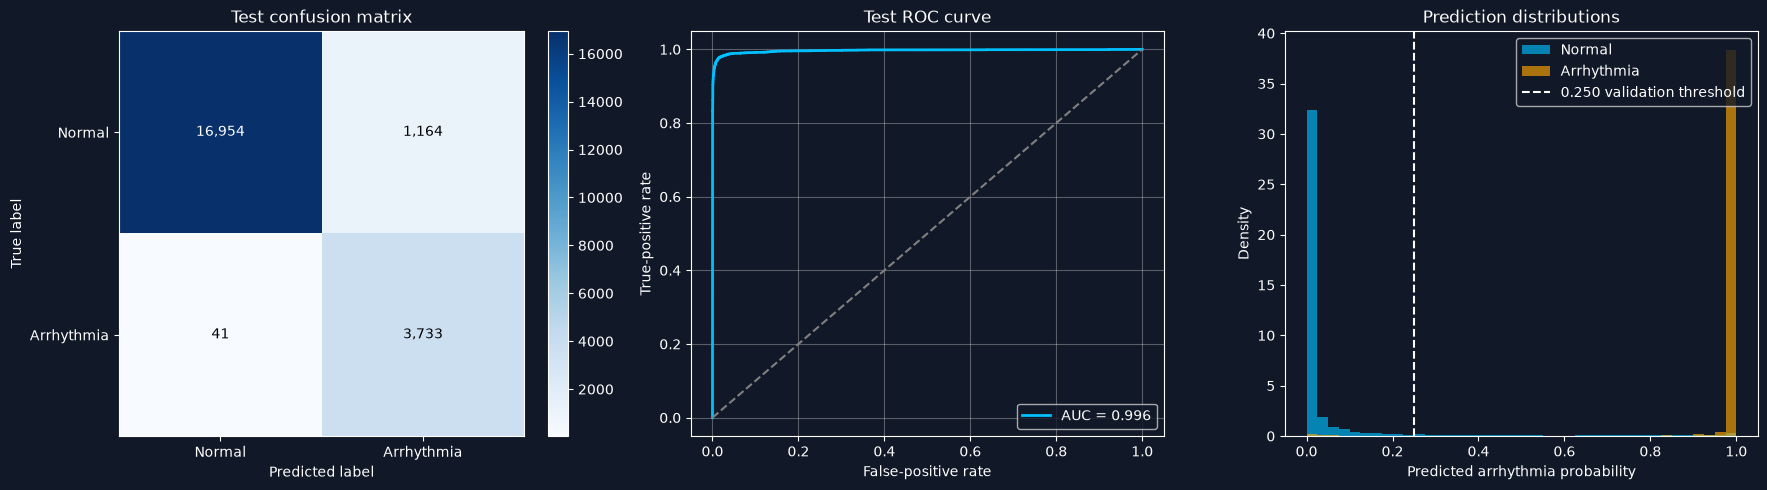

In [33]:
def roc_curve_points(labels, probabilities):
    labels = np.asarray(labels, dtype=np.int64)
    probabilities = np.asarray(probabilities)
    order = np.argsort(-probabilities, kind='stable')
    sorted_labels = labels[order]
    sorted_probabilities = probabilities[order]
    threshold_indices = np.r_[
        np.where(np.diff(sorted_probabilities))[0],
        len(sorted_probabilities) - 1,
    ]
    true_positives = np.cumsum(sorted_labels)[threshold_indices]
    false_positives = 1 + threshold_indices - true_positives
    tpr = np.r_[0, true_positives / (labels == 1).sum()]
    fpr = np.r_[0, false_positives / (labels == 0).sum()]
    return fpr, tpr


figure, axes = plt.subplots(1, 3, figsize=(18, 5))

confusion = test_metrics['confusion']
image = axes[0].imshow(confusion, cmap='Blues')
figure.colorbar(image, ax=axes[0], fraction=0.046)
axes[0].set_xticks([0, 1], labels=['Normal', 'Arrhythmia'])
axes[0].set_yticks([0, 1], labels=['Normal', 'Arrhythmia'])
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')
axes[0].set_title('Test confusion matrix')
for row in range(2):
    for column in range(2):
        axes[0].text(
            column,
            row,
            f'{confusion[row, column]:,}',
            ha='center',
            va='center',
            color='white' if (row, column) == (0, 0) else 'black',
        )

fpr, tpr = roc_curve_points(test_true_labels, test_probabilities)
axes[1].plot(fpr, tpr, color='deepskyblue', linewidth=2,
             label=f'AUC = {test_metrics["roc_auc"]:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_xlabel('False-positive rate')
axes[1].set_ylabel('True-positive rate')
axes[1].set_title('Test ROC curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].hist(test_probabilities[test_true_labels == 0], bins=40, alpha=0.65,
             label='Normal', color='deepskyblue', density=True)
axes[2].hist(test_probabilities[test_true_labels == 1], bins=40, alpha=0.65,
             label='Arrhythmia', color='orange', density=True)
axes[2].axvline(
    FINAL_DECISION_THRESHOLD,
    linestyle='--',
    color='white',
    label=f'{FINAL_DECISION_THRESHOLD:.3f} validation threshold',
)
axes[2].set_xlabel('Predicted arrhythmia probability')
axes[2].set_ylabel('Density')
axes[2].set_title('Prediction distributions')
axes[2].legend()

plt.tight_layout()
plt.show()